# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [2]:
# Add as many cells as you need
df = pd.read_csv("zillow_cleaned.csv")
df

,parcelid,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet6,fireplacecnt,...,threequarterbathnbr,typeconstructiontypeid,unitcnt,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,censustractandblock,taxvaluedollarcnt
0,14297519,0.0,3.5,4.0,NaN,3.5,3100.0,3100.0,0.0,0.0,...,1.0,NaN,NaN,1998.0,NaN,0,2016.0,NaN,6.059063e+13,1023282.0
1,17052889,0.0,1.0,2.0,NaN,1.0,1465.0,1465.0,0.0,1.0,...,0.0,NaN,NaN,1967.0,1.0,0,2016.0,NaN,6.111001e+13,464000.0
2,14186244,0.0,2.0,3.0,NaN,2.0,1243.0,1243.0,0.0,0.0,...,0.0,NaN,NaN,1962.0,1.0,0,2016.0,NaN,6.059022e+13,564778.0
3,12177905,0.0,3.0,4.0,8.0,3.0,2376.0,2376.0,0.0,0.0,...,0.0,NaN,1.0,1970.0,NaN,0,2016.0,NaN,6.037300e+13,145143.0
4,10887214,1.0,3.0,3.0,8.0,3.0,1312.0,1312.0,0.0,0.0,...,0.0,NaN,1.0,1964.0,NaN,0,2016.0,NaN,6.037124e+13,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,10833991,1.0,3.0,3.0,8.0,3.0,1741.0,1741.0,0.0,0.0,...,0.0,NaN,1.0,1980.0,NaN,0,2016.0,NaN,6.037132e+13,379000.0
77609,11000655,0.0,2.0,2.0,6.0,2.0,1286.0,1286.0,0.0,0.0,...,0.0,NaN,1.0,1940.0,NaN,0,2016.0,NaN,6.037101e+13,354621.0
77610,17239384,0.0,2.0,4.0,NaN,2.0,1612.0,1612.0,0.0,1.0,...,0.0,NaN,NaN,1964.0,1.0,0,2016.0,NaN,6.111008e+13,67205.0
77611,12773139,1.0,1.0,3.0,4.0,1.0,1032.0,1032.0,0.0,0.0,...,0.0,NaN,1.0,1954.0,NaN,0,2016.0,NaN,6.037434e+13,49546.0


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

In [3]:
# Add as many code cells as needed.
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 

X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_num = X.select_dtypes(include='number')


X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y, test_size=0.2, random_state=42)
 
    
hgbr = HistGradientBoostingRegressor()
hgbr.fit(X_train_num,y_train_num)
hgbr_pred = hgbr.predict(X_test_num)

neg_MAE_scores = cross_val_score(hgbr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_hgbr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_hgbr = -np.std(neg_MAE_scores)

In [4]:
print(mean_cv_MAE_hgbr)
print(std_mae_hgbr)

196607.7376950603
-3151.1750636790134


In [8]:
from sklearn.ensemble import ExtraTreesRegressor
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
dtr.fit(X_train_num,y_train_num)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(dtr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_dtr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_dtr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_dtr)
print(std_mae_dtr)

197479.59821578872
-2445.0991630357066


In [10]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
rgr.fit(X_sample,y_sample)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(rgr, 
                                 X_sample, y_sample,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_rgr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_rgr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_rgr)
print(std_mae_rgr)

223511.3648231512
-18972.639046812154


In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error #to test overfit vs underfit, hist boosting regression
train_pred = hgbr.predict(X_train_num)
train_MAE = mean_absolute_error(y_train_num, train_pred)

print("Train MAE:", train_MAE)
print("CV MAE:", mean_cv_MAE_hgbr)


Train MAE: 187633.97561423492
CV MAE: 196607.7376950603


In [13]:
train_pred = rgr.predict(X_train_num) #rgr 
train_MAE = mean_absolute_error(y_train_num, train_pred)

print("Train MAE:", train_MAE)
print("CV MAE:", mean_cv_MAE_hgbr)

Train MAE: 206264.4639696008
CV MAE: 196607.7376950603


In [14]:
train_pred = dtr.predict(X_train_num) #rgr 
train_MAE = mean_absolute_error(y_train_num, train_pred)

print("Train MAE:", train_MAE)
print("CV MAE:", mean_cv_MAE_hgbr)

Train MAE: 171967.14678323315
CV MAE: 196607.7376950603


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

The Decision Tree Regressor had the lowest MAE score

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

The Decision Tree Regressor had the lowest STD as well. This likely suggests that this model is the most stable when compared to the actual trend of the data.


#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

The random forest regressor and hist boosting regression both seemed to underfit due to its high training MAE compared to the decision tree regressor. 

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

the decision tree regressor consistently performed the best, with its low STD and its lowest CV MAE score.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats). 
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

In [5]:
# Add as many code cells as needed.

#idea 1: log transform on taxvaluedollarcnt and calcfinished squarefeet
# print(df['taxvaluedollarcnt'])
# print(df['calculatedfinishedsquarefeet'])
df['taxvaluedollarcnt'] = np.log1p(df['taxvaluedollarcnt'])
df['calculatedfinishedsquarefeet'] = np.log1p(df['calculatedfinishedsquarefeet'])
# print(df['taxvaluedollarcnt'])
# print(df['calculatedfinishedsquarefeet'])

repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 

X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_num = X.select_dtypes(include='number')


X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y, test_size=0.2, random_state=42)
 
    
hgbr = HistGradientBoostingRegressor()
hgbr.fit(X_train_num,y_train_num)
hgbr_pred = hgbr.predict(X_test_num)

neg_MAE_scores = cross_val_score(hgbr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_hgbr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_hgbr = -np.std(neg_MAE_scores)

In [7]:
print(mean_cv_MAE_hgbr)
print(std_mae_hgbr)

0.03572846543721728
-0.00024016472727848246


In [8]:
from sklearn.ensemble import ExtraTreesRegressor
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
dtr.fit(X_train_num,y_train_num)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(dtr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_dtr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_dtr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_dtr)
print(std_mae_dtr)

0.036216239344163
-0.00023599073002424073


In [9]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
rgr.fit(X_sample,y_sample)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(rgr, 
                                 X_sample, y_sample,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_rgr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_rgr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_rgr)
print(std_mae_rgr)

0.04273118645736131
-0.005385389009602049


In [13]:
#idea 2, capping outliers 

"""The Interquartile Range (IQR) is a statistical measure of spread that describes the middle 50% of a dataset"""

#refresh df
df = pd.read_csv("zillow_cleaned.csv")
def cap_outliers_iqr(df, columns, k=1.5):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)#pick two bounds to look out for and base the capping off of
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped

X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
numeric_cols = X_num.columns.tolist()
X_train_num_capped = cap_outliers_iqr(X_train_num, numeric_cols, k=1.5)
X_test_num_capped= cap_outliers_iqr(X_test_num, numeric_cols, k=1.5)

hgbr_capped = HistGradientBoostingRegressor()
hgbr_capped.fit(X_train_num_capped, y_train_num)
hgbr_pred_capped = hgbr_capped.predict(X_test_num_capped)

neg_MAE_scores_capped = cross_val_score(
    hgbr_capped,
    X_train_num_capped, y_train_num,
    scoring='neg_mean_absolute_error',
    cv=repeated_cv,
    n_jobs=-1
)

mean_cv_MAE_hgbr_capped = -np.mean(neg_MAE_scores_capped)
std_mae_hgbr_capped = -np.std(neg_MAE_scores_capped)

print(mean_cv_MAE_hgbr_capped)
print(std_mae_hgbr_capped)

0.03568663115372388
-0.0002485614725529291


In [14]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
dtr.fit(X_train_num_capped,y_train_num)

neg_MAE_scores_capped = cross_val_score(
    dtr,
    X_train_num_capped, y_train_num,
    scoring='neg_mean_absolute_error',
    cv=repeated_cv,
    n_jobs=-1
)

mean_cv_MAE_hgbr_capped = -np.mean(neg_MAE_scores_capped)
std_mae_hgbr_capped = -np.std(neg_MAE_scores_capped)

print(mean_cv_MAE_hgbr_capped)
print(std_mae_hgbr_capped)

0.03613614843626237
-0.00024989628679662117


In [16]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42)
    
rgr.fit(X_train_num_capped,y_train_num)

neg_MAE_scores_capped = cross_val_score(
    rgr,
    X_train_num_capped, y_train_num,
    scoring='neg_mean_absolute_error',
    cv=repeated_cv,
    n_jobs=-1
)

mean_cv_MAE_hgbr_capped = -np.mean(neg_MAE_scores_capped)
std_mae_hgbr_capped = -np.std(neg_MAE_scores_capped)

print(mean_cv_MAE_hgbr_capped)
print(std_mae_hgbr_capped)

0.03571982949261295
-0.0002469220782095835


In [20]:
#idea 3, dropping redundant features
df = pd.read_csv("zillow_cleaned.csv")
df = df.drop(columns=['bathroomcnt','finishedsquarefeet12'])
print(df.columns)
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 

X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_num = X.select_dtypes(include='number')


X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y, test_size=0.2, random_state=42)
 
    
hgbr = HistGradientBoostingRegressor()
hgbr.fit(X_train_num,y_train_num)
hgbr_pred = hgbr.predict(X_test_num)

neg_MAE_scores = cross_val_score(hgbr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_hgbr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_hgbr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_hgbr)
print(std_mae_hgbr)

Index(['parcelid', 'airconditioningtypeid', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedbathnbr',
       'calculatedfinishedsquarefeet', 'finishedsquarefeet6', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum',
       'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'rawcensustractandblock', 'regionidcity', 'regionidcounty',
       'regionidzip', 'roomcnt', 'storytypeid', 'threequarterbathnbr',
       'typeconstructiontypeid', 'unitcnt', 'yearbuilt', 'numberofstories',
       'fireplaceflag', 'assessmentyear', 'taxdelinquencyflag',
       'censustractandblock', 'taxvaluedollarcnt'],
      dtype='object')
196293.6189118428
-2600.9031143435727


In [21]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
dtr.fit(X_train_num,y_train_num)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(dtr, 
                                 X_train_num, y_train_num,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_dtr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_dtr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_dtr)
print(std_mae_dtr)

196917.65878268774
-2462.4355550615956


In [22]:
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 
 
    
rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
X_sample = X_train_num.sample(5000, random_state=42) #testing if model works
y_sample = y_train_num.loc[X_sample.index]
rgr.fit(X_sample,y_sample)
#dtr_pred = dtr.predict(X_test_num)

neg_MAE_scores = cross_val_score(rgr, 
                                 X_sample, y_sample,
                                 scoring='neg_mean_absolute_error',            
                                 cv=repeated_cv,
                                 n_jobs=-1)

mean_cv_MAE_rgr = -np.mean(neg_MAE_scores)  # Convert negative MAE back to positive
std_mae_rgr = -np.std(neg_MAE_scores)

print(mean_cv_MAE_rgr)
print(std_mae_rgr)

224408.82680682727
-19901.493977948525


### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

The log transforms as well as the capping of outliers in the data both resulted in significant reductions of MAE and Stdev of the error, but the latter method provided a more consistent and slightly larger reduction in error. 

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

All methods were successful due to them all reducing MAE and Stdev, though the dropping of redundant columns provided a very small reduction. Nevertheless it never raised the error.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

The log transformations and the capping of outliers massively benefitted the model, likely due to their greater effect in streamlining inconsistencies in the data and its patterns. Dropping repetitive columns do not seem to affect the overall trend as much as the former inconsistencies are left untouched which more directly hurt the model's performance.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

The first two methods will definetly be utilized in the remainder of the milestone. They provided an extremely fruitful reduction of error in the data. However, due to their production of near 0 MAEs, it is possible these are causing overfitting to the data.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [3]:
# Add as many code cells as needed.
#defining baseline stuff. rereading a clean df, defining models, performing feature engineering

df = pd.read_csv("zillow_cleaned.csv")# refresh df

from sklearn.ensemble import ExtraTreesRegressor
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 

rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
)    

hgbr = HistGradientBoostingRegressor()

#reimplementing best feature cleaning methods

df['taxvaluedollarcnt'] = np.log1p(df['taxvaluedollarcnt'])
df['calculatedfinishedsquarefeet'] = np.log1p(df['calculatedfinishedsquarefeet'])
    
def cap_outliers_iqr(df, columns, k=1.5):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)#pick two bounds to look out for and base the capping off of
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped
    
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
    
X_num = X.select_dtypes(include='number')
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
numeric_cols = X_num.columns.tolist()
X_train_num_capped = cap_outliers_iqr(X_train_num, numeric_cols, k=1.5)
X_test_num_capped= cap_outliers_iqr(X_test_num, numeric_cols, k=1.5)

In [5]:
from sklearn.inspection import permutation_importance #method of feature selection
from sklearn.base import clone
def compute_permutation_importance(X, y, model,
                                    n_splits=5,
                                    n_repeats=5,
                                    random_state=None,
                                    n_perm_repeats=10,
                                    n_jobs=-1,
                                    ):
    """
    Fits `model` across a RepeatedKFold split (same scheme used elsewhere
    for MAE evaluation) and computes permutation importance on each fold's
    held-out validation slice. Importances are averaged across all folds
    to reduce noise from any single split.
 
    Works identically for DecisionTreeRegressor, RandomForestRegressor,
    and HistGradientBoostingRegressor -- unlike feature_importances_,
    which HistGradientBoostingRegressor does not expose.
 
    Returns:
        importance_df_sorted : list of (feature_name, mean_importance, std_importance)
                                sorted from most to least important
        raw_importances      : dict[feature_name] -> list of per-fold mean importances
    """
    feature_names = list(X.columns)
    repeated_cv = RepeatedKFold(n_splits=n_splits,
                                 n_repeats=n_repeats,
                                 random_state=random_state)
 
    raw_importances = {feature: [] for feature in feature_names}
 
    for train_idx, val_idx in repeated_cv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
 
        result = permutation_importance(fold_model, X_val, y_val,
                                         scoring='neg_mean_absolute_error',
                                         n_repeats=n_perm_repeats,
                                         random_state=random_state,
                                         n_jobs=n_jobs)
 
        for i, feature in enumerate(feature_names):
            raw_importances[feature].append(result.importances_mean[i])
 
    importance_summary = [
        (feature, np.mean(scores), np.std(scores))
        for feature, scores in raw_importances.items()
    ]
 
    # Sort descending: most important (largest MAE degradation when shuffled) first
    importance_summary_sorted = sorted(importance_summary, key=lambda x: x[1], reverse=True)
 
    return importance_summary_sorted, raw_importances

In [6]:
def permutation_backward_elimination(X, y, model, #applying the above function to drop 
                                      n_splits=5,
                                      n_repeats=5,
                                      random_state=None,
                                      n_perm_repeats=10,
                                      n_jobs=-1,
                                      tol=None,       # None = no early stop; 0.0 = stop if MAE stops improving
                                      verbose=False,
                                      ):
    """
    Greedy backward elimination for tree-based models (DecisionTreeRegressor,
    RandomForestRegressor, HistGradientBoostingRegressor).
 
    At each step:
      1. Compute permutation importance for all remaining features.
      2. Drop the least important feature.
      3. Re-evaluate repeated CV MAE with the reduced feature set.
      4. Stop early if tol is set and MAE stops improving beyond tol.
 
    Mirrors forward_feature_selection's tracking pattern (best_scores,
    best_feature_set, best_score) but removes features instead of adding them.
 
    Returns:
        elimination_order, cv_scores, best_feature_set, best_score
    """
    remaining_features = list(X.columns)
    repeated_cv = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
 
    elimination_order = []   # Features removed, in order removed
    cv_scores = []           # CV MAE after each removal
    previous_score = float('inf')
 
    # Track the best subset seen so far
    best_feature_set = remaining_features.copy()
    best_score = float('inf')
 
    # Establish baseline MAE with all features before removing anything
    neg_mae_scores = cross_val_score(model, X[remaining_features], y,
                                      scoring='neg_mean_absolute_error',
                                      cv=repeated_cv, n_jobs=n_jobs)
    current_score = -np.mean(neg_mae_scores)
    best_score = current_score
    previous_score = current_score
 
    if verbose:
        print(f"Baseline ({len(remaining_features)} features), CV MAE: {current_score:.4f}")
 
    while len(remaining_features) > 1:
        importance_ranking, _ = compute_permutation_importance(
            X[remaining_features], y, model,
            n_splits=n_splits, n_repeats=n_repeats,
            random_state=random_state, n_perm_repeats=n_perm_repeats,
            n_jobs=n_jobs
        )
 
        # Least important feature is last in the sorted (descending) list
        feature_to_drop = importance_ranking[-1][0]
        remaining_features.remove(feature_to_drop)
        elimination_order.append(feature_to_drop)
 
        # Re-evaluate CV MAE with the reduced feature set
        neg_mae_scores = cross_val_score(model, X[remaining_features], y,
                                          scoring='neg_mean_absolute_error',
                                          cv=repeated_cv, n_jobs=n_jobs)
        current_score = -np.mean(neg_mae_scores)
        cv_scores.append(current_score)
 
        if verbose:
            print(f"Dropped '{feature_to_drop}' -> {len(remaining_features)} features, "
                  f"CV MAE: {current_score:.4f}")
 
        # Update best subset if this is the best score so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = remaining_features.copy()
 
        # Check early stopping based on tolerance
        if tol is not None and current_score - previous_score > tol:
            if verbose:
                print("Stopping early: MAE degraded beyond tolerance.")
            break
 
        previous_score = current_score
 
    return (
        elimination_order,     # Order in which features were dropped
        cv_scores,             # CV MAE after each drop
        best_feature_set,      # Best-performing feature subset found
        best_score,            # Best CV MAE achieved
    )

In [11]:
models = {
        "DecisionTree": dtr,
        "RandomForest": rgr,
        "HistGradientBoosting": hgbr,
    }

for name, model in models.items():
    
    order, scores, best_set, best_mae = permutation_backward_elimination(
        X_train_num_capped, y_train_num, model,n_splits=3, n_repeats=1, random_state=42, verbose=True)#define splits here to reduce runtime
    print(f"\n{name}: best MAE = {best_mae:.4f} with {len(best_set)} features")
    print(f"Selected features: {best_set}")
    
"""cut runtime by increasing n_repeats/n_splits for the final confirmation run but using fewer 
e.g. n_splits=3, n_repeats=1) during the elimination sweep itself"""

Baseline (33 features), CV MAE: 0.4841
Dropped 'heatingorsystemtypeid' -> 32 features, CV MAE: 0.4841
Dropped 'assessmentyear' -> 31 features, CV MAE: 0.4840
Dropped 'unitcnt' -> 30 features, CV MAE: 0.4842
Dropped 'typeconstructiontypeid' -> 29 features, CV MAE: 0.4842
Dropped 'threequarterbathnbr' -> 28 features, CV MAE: 0.4840
Dropped 'roomcnt' -> 27 features, CV MAE: 0.4843
Dropped 'pooltypeid7' -> 26 features, CV MAE: 0.4841
Dropped 'pooltypeid2' -> 25 features, CV MAE: 0.4842
Dropped 'pooltypeid10' -> 24 features, CV MAE: 0.4842
Dropped 'poolsizesum' -> 23 features, CV MAE: 0.4840
Dropped 'poolcnt' -> 22 features, CV MAE: 0.4841
Dropped 'garagetotalsqft' -> 21 features, CV MAE: 0.4839
Dropped 'fireplacecnt' -> 20 features, CV MAE: 0.4842
Dropped 'finishedsquarefeet6' -> 19 features, CV MAE: 0.4843
Dropped 'numberofstories' -> 18 features, CV MAE: 0.4841
Dropped 'garagecarcnt' -> 17 features, CV MAE: 0.4841
Dropped 'airconditioningtypeid' -> 16 features, CV MAE: 0.4843
Dropped 'ce

'cut runtime by increasing n_repeats/n_splits for the final confirmation run but using fewer \ne.g. n_splits=3, n_repeats=1) during the elimination sweep itself'

In [12]:
#first results of running the feature selection and retraining the model
dtr_mae = 0.4839
dtr_feats = 21
dtr_names = ['parcelid', 'airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 
             'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 
             'garagecarcnt', 'lotsizesquarefeet', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity', 
             'regionidcounty', 'regionidzip', 'yearbuilt', 
             'numberofstories',
'censustractandblock']

rf_mae = 0.4792
rf_feats = 33
rf_names = ['parcelid', 'airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 
            'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 
            'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 
            'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
            'regionidcounty', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'typeconstructiontypeid', 'unitcnt', 
            'yearbuilt', 'numberofstories', 'assessmentyear', 'censustractandblock']
hgbr_mae = 0.4786
hgbr_feats = 19
hgbr_names = ['parcelid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 
              'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'lotsizesquarefeet',
              'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
              'regionidcounty', 'regionidzip', 'yearbuilt', 'numberofstories', 'censustractandblock']

### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

With respect to the original models before feature engineering, the models have a greatly improved validation performance. However, when comparing with the feature engineering (capping outlier values), the model performance actually got worse as the MAE rose by a factor of 10. This shows that a variety of features are integral to the validation process

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?
Many features were retained across all models:


Consistently retained: parcelid, bathroomcnt,bedroomcnt,buildingqualitytypeid,regionidcity,regionidzip,regionidcounty,finishedsquarefeet12, finishedsquarefeet6, fireplacecnt, garagecarcnt, lotsizesquarefeet, among others

Consistently DROPPED: roomcnt, assessmentyear, poolsizesum, 
            pooltypeid10, pooltypeid2, pooltypeid7

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

Yes, the log transform on calculated square feet was retained by all three models as an important feature. It confirms that the right skewed nature of the pre-transformed feature was neatively impacting the model's performance, and adjusting for that helps it massively.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

The simpler models did not perform as well as the purely feature engineered sets with the full feature count. This hints that model complexity is heavily correlated with good model performance. However, those features must be tweaked to further optimize performance. 

> Your text here

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats). 
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [5]:
df = pd.read_csv("zillow_cleaned.csv")# refresh df
df  = df[['parcelid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 
              'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'lotsizesquarefeet',
              'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
              'regionidcounty', 'regionidzip', 'yearbuilt', 'numberofstories', 'censustractandblock']]
#type(df)


pandas.core.frame.DataFrame

In [3]:
# Add as many code cells as needed.
#defining baseline stuff. rereading a clean df, defining models, performing feature engineering

df = pd.read_csv("zillow_cleaned.csv")# refresh df
df  = df[['parcelid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 
              'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'lotsizesquarefeet',
              'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
              'regionidcounty', 'regionidzip', 'yearbuilt', 'numberofstories', 'censustractandblock','taxvaluedollarcnt']]
from sklearn.ensemble import ExtraTreesRegressor
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           ) 

rgr = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
    random_state=42
)
    
dtr = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=15,        # or None + max_leaf_nodes instead
    min_samples_leaf=5,  # prevents tiny leaves that bloat tree size
    n_jobs=1,             # see point 2
)    

hgbr = HistGradientBoostingRegressor()

#reimplementing best feature cleaning methods

df['taxvaluedollarcnt'] = np.log1p(df['taxvaluedollarcnt'])
df['calculatedfinishedsquarefeet'] = np.log1p(df['calculatedfinishedsquarefeet'])
    
def cap_outliers_iqr(df, columns, k=1.5):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)#pick two bounds to look out for and base the capping off of
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped
    
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
    
X_num = X.select_dtypes(include='number')
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
numeric_cols = X_num.columns.tolist()
X_train_num_capped = cap_outliers_iqr(X_train_num, numeric_cols, k=1.5)
X_test_num_capped= cap_outliers_iqr(X_test_num, numeric_cols, k=1.5)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:40<00:00,  2.14s/it]


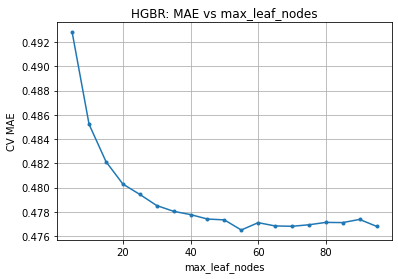

Best max_leaf_nodes: 55, MAE = 0.4765 ± 0.0032


In [8]:
#first sweep different parameters for each model to tune the right ones that minimize mae
#starting with hist boosting regressor, benefitting from max_leaf_nodes

from tqdm import tqdm
from sklearn.model_selection import KFold, cross_val_score

def sweep_parameter(model_class, fixed_params, param_name, param_values, X, y, cv=5):
    means, stds = [], []
    for v in tqdm(param_values):
        params = {**fixed_params, param_name: v}
        model = model_class(**params)
        scores = cross_val_score(
            model, X, y,
            cv=KFold(n_splits=cv, shuffle=True, random_state=42),
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        means.append(-scores.mean())
        stds.append(scores.std())
    return means, stds

# Sweep max_leaf_nodes for HGBR (a key regularization knob for this model)
param_name = 'max_leaf_nodes'
param_values = list(range(5, 100, 5))

fixed_params = {'random_state': 42}  # keep everything else default while sweeping

means, stds = sweep_parameter(
    HistGradientBoostingRegressor, fixed_params, param_name, param_values,
    X_train_num_capped, y_train_num
)

plt.figure(figsize=(6,4))
plt.plot(param_values, means, marker='.')
plt.xlabel(param_name)
plt.ylabel('CV MAE')
plt.title(f'HGBR: MAE vs {param_name}')
plt.grid()
plt.show()

best_idx = int(np.argmin(means))
print(f"Best {param_name}: {param_values[best_idx]}, found at MAE = {means[best_idx]:.4f} ± {stds[best_idx]:.4f}")

In [9]:
#initial evaluation with a random range of param values within the minimum plateau on the graph
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'max_leaf_nodes': randint(10, 45),        # narrowed based on the plateau above
    'learning_rate': uniform(0.02, 0.18),     # e.g. 0.02 to 0.20
    'max_iter': randint(50, 300),
}

hgbr_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

hgbr_search.fit(X_train_num_capped, y_train_num)

print("Best params:", hgbr_search.best_params_)
print("Best CV MAE:", -hgbr_search.best_score_)

Best params: {'learning_rate': 0.08421559880484607, 'max_iter': 237, 'max_leaf_nodes': 38}
Best CV MAE: 0.476645373204307


In [10]:
#use ideal params in final model

repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
param_distributions = {
    'max_leaf_nodes': 38,        # narrowed based on the ideal vals
    'learning_rate': 0.08421559880484607,    
    'max_iter': 237,
}
hgbr_final = HistGradientBoostingRegressor(**param_distributions)

final_scores = cross_val_score(
    hgbr_final, X_train_num_capped, y_train_num,
    cv=repeated_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

final_mae_mean = -final_scores.mean()
final_mae_std = final_scores.std()

print(f"Tuned HGBR — Repeated 5x5 CV MAE: {final_mae_mean:.4f} ± {final_mae_std:.4f}")

Tuned HGBR — Repeated 5x5 CV MAE: 0.4774 ± 0.0033


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [13:59<00:00, 44.19s/it]


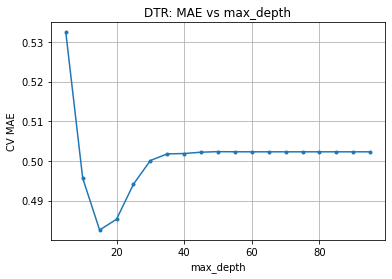

Best max_depth: 15, found at MAE = 0.4826 ± 0.0039


In [11]:
#retry for other models, now decision trees
param_name = 'max_depth'
param_values = list(range(5, 100, 5))

fixed_params = {'random_state': 42}  # keep everything else default while sweeping

means, stds = sweep_parameter(
    ExtraTreesRegressor, fixed_params, param_name, param_values,
    X_train_num_capped, y_train_num
)

plt.figure(figsize=(6,4))
plt.plot(param_values, means, marker='.')
plt.xlabel(param_name)
plt.ylabel('CV MAE')
plt.title(f'DTR: MAE vs {param_name}')
plt.grid()
plt.show()

best_idx = int(np.argmin(means))
print(f"Best {param_name}: {param_values[best_idx]}, found at MAE = {means[best_idx]:.4f} ± {stds[best_idx]:.4f}")


In [13]:
param_distributions = {
    'max_depth': randint(5, 25),        # narrowed based on the plateau above
    'min_samples_leaf': randint(2, 7),     
    'max_features': randint(15, 50),
}

dtr_search = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

dtr_search.fit(X_train_num_capped, y_train_num)

print("Best params:", dtr_search.best_params_)
print("Best CV MAE:", -dtr_search.best_score_)

Best params: {'max_depth': 18, 'max_features': 45, 'min_samples_leaf': 5}
Best CV MAE: 0.48099639154881035


In [14]:
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
param_distributions = {
    'max_depth': 18,        # narrowed based on the ideal vals
    'max_features': 45,    
    'min_samples_leaf': 5,
}
dtr_final = ExtraTreesRegressor(**param_distributions)

final_scores = cross_val_score(
    dtr_final, X_train_num_capped, y_train_num,
    cv=repeated_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

final_mae_mean = -final_scores.mean()
final_mae_std = final_scores.std()

print(f"Tuned DTR — Repeated 5x5 CV MAE: {final_mae_mean:.4f} ± {final_mae_std:.4f}")

Tuned DTR — Repeated 5x5 CV MAE: 0.4811 ± 0.0031


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [28:38<00:00, 90.44s/it]


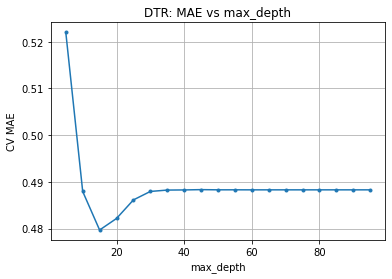

Best max_depth: 15, found at MAE = 0.4797 ± 0.0041


In [15]:
#retry for other models, now random forest regressor
param_name = 'max_depth'
param_values = list(range(5, 100, 5))

fixed_params = {'random_state': 42}  # keep everything else default while sweeping

means, stds = sweep_parameter(
    RandomForestRegressor, fixed_params, param_name, param_values,
    X_train_num_capped, y_train_num
)

plt.figure(figsize=(6,4))
plt.plot(param_values, means, marker='.')
plt.xlabel(param_name)
plt.ylabel('CV MAE')
plt.title(f'RFR: MAE vs {param_name}')
plt.grid()
plt.show()

best_idx = int(np.argmin(means))
print(f"Best {param_name}: {param_values[best_idx]}, found at MAE = {means[best_idx]:.4f} ± {stds[best_idx]:.4f}")

In [18]:
param_distributions = {
    'max_depth': randint(5, 20),        # narrowed based on the plateau above
    'min_samples_leaf': randint(2, 6),     
    'max_features': randint(15, 40),
}

rfr_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

dtr_search.fit(X_train_num_capped, y_train_num)

print("Best params:", dtr_search.best_params_)
print("Best CV MAE:", -dtr_search.best_score_)

Best params: {'max_depth': 18, 'max_features': 45, 'min_samples_leaf': 5}
Best CV MAE: 0.48099639154881035


In [17]:
repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
param_distributions = {
    'max_depth': 18,        # narrowed based on the ideal vals
    'max_features': 45,    
    'min_samples_leaf': 5,
}
rfr_final = RandomForestRegressor(**param_distributions)

final_scores = cross_val_score(
    rfr_final, X_train_num_capped, y_train_num,
    cv=repeated_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

final_mae_mean = -final_scores.mean()
final_mae_std = final_scores.std()

print(f"Tuned RFR — Repeated 5x5 CV MAE: {final_mae_mean:.4f} ± {final_mae_std:.4f}")

Tuned DTR — Repeated 5x5 CV MAE: 0.4786 ± 0.0033


### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

The HGBR's max leaf nodes caused that model to have the greatest decrease in MAE. Optimizing this parameter controls the complexity of the model and prevents any extraneous fitting.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

Compared to the feature dropping exercise improvements, the HGBR improved the most in terms of its MAE score. The other two had negligible changes in MAE.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

I employed the sweeping and narrowing of hyperparameter values employed in Homework 6, as this was a framework that was easiest to interpret and reapply. It allows for a top-to-bottom scanning of all the params in the model and narrows which ones cause the most change in MAE, then allows to hone in on a specific value that improves it most. 

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

The HGBR model performed the best after performance tuning relative to the results from the feature engineering. 

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [29]:
# Add as many code cells as needed.
"""combining the results of all the tests, we will use the HGBR with the outlier capping feature engineering, as well as
hyperparameter tuning and the selection of columns found to be most impactful as per Part 3. Though the outlier capping initially\
overfit the data, the combination with other methods added back some nuance to the data to bring it back down to a reasonable 
value (near 0 vs 0.48)
"""

In [4]:
#defining baseline stuff. rereading a clean df, defining models, performing feature engineering

df = pd.read_csv("zillow_cleaned.csv")# refresh df
df  = df[['parcelid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 
              'finishedsquarefeet12', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'lotsizesquarefeet',
              'poolcnt', 'propertylandusetypeid', 'rawcensustractandblock', 'regionidcity',
              'regionidcounty', 'regionidzip', 'yearbuilt', 'numberofstories', 'censustractandblock','taxvaluedollarcnt']]
from sklearn.ensemble import ExtraTreesRegressor
repeated_cv = RepeatedKFold(n_splits     = 5, 
                            n_repeats    = 5,
                            random_state = 42
                           )  

hgbr = HistGradientBoostingRegressor()

#reimplementing best feature cleaning methods

df['taxvaluedollarcnt'] = np.log1p(df['taxvaluedollarcnt'])
df['calculatedfinishedsquarefeet'] = np.log1p(df['calculatedfinishedsquarefeet'])
    
def cap_outliers_iqr(df, columns, k=1.5):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)#pick two bounds to look out for and base the capping off of
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped
    
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt'].fillna(0)
    
X_num = X.select_dtypes(include='number')
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
numeric_cols = X_num.columns.tolist()
X_train_num_capped = cap_outliers_iqr(X_train_num, numeric_cols, k=1.5)
X_test_num_capped= cap_outliers_iqr(X_test_num, numeric_cols, k=1.5)

100%|███████████████████████████████████████████████████████████████████████████████████| 19/19 [00:44<00:00,  2.33s/it]


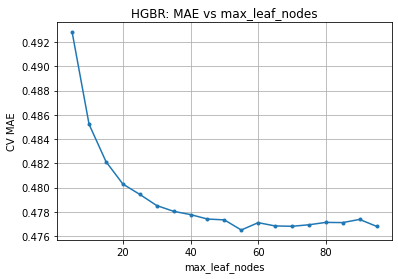

Best max_leaf_nodes: 55, found at MAE = 0.4765 ± 0.0032


In [7]:
from tqdm import tqdm
from sklearn.model_selection import KFold, cross_val_score

def sweep_parameter(model_class, fixed_params, param_name, param_values, X, y, cv=5):
    means, stds = [], []
    for v in tqdm(param_values):
        params = {**fixed_params, param_name: v}
        model = model_class(**params)
        scores = cross_val_score(
            model, X, y,
            cv=KFold(n_splits=cv, shuffle=True, random_state=42),
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        means.append(-scores.mean())
        stds.append(scores.std())
    return means, stds

# Sweep max_leaf_nodes for HGBR (a key regularization knob for this model)
param_name = 'max_leaf_nodes'
param_values = list(range(5, 100, 5))

fixed_params = {'random_state': 42}  # keep everything else default while sweeping

means, stds = sweep_parameter(
    HistGradientBoostingRegressor, fixed_params, param_name, param_values,
    X_train_num_capped, y_train_num
)

plt.figure(figsize=(6,4))
plt.plot(param_values, means, marker='.')
plt.xlabel(param_name)
plt.ylabel('CV MAE')
plt.title(f'HGBR: MAE vs {param_name}')
plt.grid()
plt.show()

best_idx = int(np.argmin(means))
print(f"Best {param_name}: {param_values[best_idx]}, found at MAE = {means[best_idx]:.4f} ± {stds[best_idx]:.4f}")

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'max_leaf_nodes': randint(10, 45),        # narrowed based on the plateau above
    'learning_rate': uniform(0.02, 0.18),     # e.g. 0.02 to 0.20
    'max_iter': randint(50, 300),
}

hgbr_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42
)

hgbr_search.fit(X_train_num_capped, y_train_num)

print("Best params:", hgbr_search.best_params_)

Best params: {'learning_rate': 0.08421559880484607, 'max_iter': 237, 'max_leaf_nodes': 38}


In [14]:
#use ideal params in final model

repeated_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
param_distributions = {
    'max_leaf_nodes': 38,        # narrowed based on the ideal vals
    'learning_rate': 0.08421559880484607,    
    'max_iter': 237,
}
hgbr_final = HistGradientBoostingRegressor(**param_distributions)

final_scores = cross_val_score(
    hgbr_final, X_train_num_capped, y_train_num,
    cv=repeated_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

final_mae_mean = -final_scores.mean()
final_mae_std = final_scores.std()

print(f"Tuned HGBR — Repeated 5x5 CV MAE: {final_mae_mean:.4f} ± {final_mae_std:.4f}")


Tuned HGBR — Repeated 5x5 CV MAE: 0.4773 ± 0.0037


In [15]:
from sklearn.metrics import mean_absolute_error,mean_squared_error #to test overfit vs underfit, hist boosting regression
hgbr_final.fit(X_train_num_capped, y_train_num)
predictions = hgbr_final.predict(X_test_num_capped)
final_mae = mean_absolute_error(y_test_num,predictions)
print(final_mae)

0.4785747845235317


### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

0.4785747845235317 final vs 196607.7376950603 ± 3151.1750636790134 initial

There was a significant improvement in the model after performing all the engineering steps. The outlier capping provided an extreme decrease in the MAE to the point of potential overfitting, but the feature selection helped bring it back to a reasonable range, and the hyperparameter tuning provided extra tweaks towards improvement to arrive at the final score.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

The hypothesis to cap outlier values for feature engineering as well as the log transform on specific columns were very successful in reducing MAE as it accounted for the right skew in the data. However they may have overfitted the model to the data as the MAE score was very low. The dropping of redundant columns seemed to disprove our hypothesis of that engineering method being beneficial, the improvements to the MAEs of the 3 different models were small. 

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

The HGBR proved to be the most responsive to all model improvements and feature engineering, and is overall the easiest to use in terms of parameters and parameter tuning. For the latter improvements, it depended on unique parameters compared to the other regression methods and produced a more distinct result of important parameters to tune. Its final result after tuning the params produced a better MAE as well.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

We now have a concrete example as to the importance of feature engineering and the involvment needed in machine learning. You cannot simply take the datasets as is, there lie intrisic issues with the data that need to be addressed before training models to draw insights. Even with some of these methods, you must reserve judgement on immediately ruling one as a win versus a loss; multiple methods should be used in conjunction to form the best pipeline for improving the dataset for analysis. 

If there was more time, we would investigate the degree to which the initial feature engineering caused overfitting in the model, and how specifically it was manifesting, maybe through a comparitive graph or heatmap of the data relationships. The sheer drop in MAE is deceptively good but cannot be used on its own.